<a href="https://colab.research.google.com/github/sandeepyelekar2/GenAIDeveloper_training/blob/Bronze_Badge_for_Gen_AIAssessment/Assignment_1_Employee_Productivity_Scores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
# Import Libraries
# Imports Pandas for data manipulation and analysis.
import pandas as pd
# Imports NumPy for numerical and array operations.
import numpy as np
# Imports Matplotlib's plotting module for creating visualizations.
import matplotlib.pyplot as plt
# Imports Seaborn for advanced statistical data visualization.
import seaborn as sns
#Imports Linear Regression model for predictive analysis.
from sklearn.linear_model import LinearRegression
# Imports function to split data into training and testing sets.
from sklearn.model_selection import train_test_split
# Imports metrics to evaluate regression model performance.
from sklearn.metrics import mean_squared_error, r2_score

In [38]:
# Create the dataset , Also We can use CSV to store data
data = {
    "Experience": [2,5,1,8,4,10,3,6,7,2],
    "Training_Hours": [40,60,20,80,50,90,30,70,75,25],
    "Working_Hours": [38,42,35,45,40,48,37,44,46,36],
    "Projects": [3,6,2,8,5,9,4,7,7,3],
    "Productivity_Score": [62,78,55,88,72,92,65,82,85,60]
}

# Convert into DataFrame
df = pd.DataFrame(data)

# Display dataset
df

,Experience,Training_Hours,Working_Hours,Projects,Productivity_Score
0,2,40,38,3,62
1,5,60,42,6,78
2,1,20,35,2,55
3,8,80,45,8,88
4,4,50,40,5,72
5,10,90,48,9,92
6,3,30,37,4,65
7,6,70,44,7,82
8,7,75,46,7,85
9,2,25,36,3,60


In [42]:
print(df.head())

print()

print(df.describe())

print()

print(df.info())

   Experience  Training_Hours  Working_Hours  Projects  Productivity_Score
0           2              40             38         3                  62
1           5              60             42         6                  78
2           1              20             35         2                  55
3           8              80             45         8                  88
4           4              50             40         5                  72

       Experience  Training_Hours  Working_Hours   Projects  \
count   10.000000       10.000000      10.000000  10.000000   
mean     4.800000       54.000000      41.100000   5.400000   
std      2.936362       24.698178       4.557046   2.366432   
min      1.000000       20.000000      35.000000   2.000000   
25%      2.250000       32.500000      37.250000   3.250000   
50%      4.500000       55.000000      41.000000   5.500000   
75%      6.750000       73.750000      44.750000   7.000000   
max     10.000000       90.000000      48.000

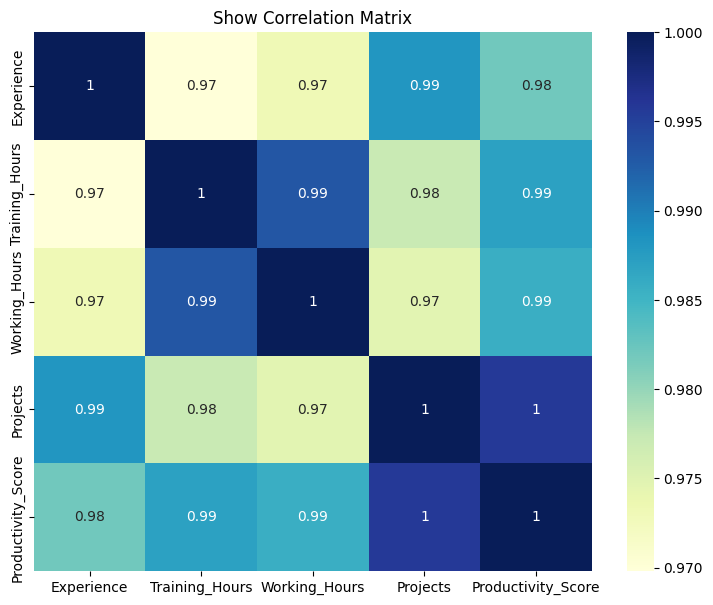

In [47]:
plt.figure(figsize=(9,7))

sns.heatmap(df.corr(),annot=True,cmap="YlGnBu")

plt.title("Show Correlation Matrix")

plt.show()

In [50]:
# Select input features
X = df[["Experience","Training_Hours","Working_Hours","Projects"]]

# Select output variable
y = df["Productivity_Score"]

In [54]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=44
)
# Create Linear Regression model
model = LinearRegression()
# Train the model
model.fit(X_train, y_train)


LinearRegression()

In [55]:
print("Intercept")

print(model.intercept_)

print()

print("Coefficients")

for feature,coef in zip(X.columns,model.coef_):
    print(feature,":",coef)

Intercept
5.021374045801508

Coefficients
Experience : -2.2335877862595437
Training_Hours : -0.00427480916030476
Working_Hours : 1.1343511450381678
Projects : 6.193893129770992


In [56]:
y_pred = model.predict(X_test)

print("Predicted Values")

print(y_pred)

Predicted Values
[54.79236641 84.58931298]


In [57]:
mse = mean_squared_error(y_test,y_pred)

r2 = r2_score(y_test,y_pred)

print("Mean Squared Error =",mse)

print("R2 Score =",r2)

Mean Squared Error = 3.373826700075766
R2 Score = 0.9814879193411481


In [58]:
new_employee = [[5,65,42,6]]

prediction = model.predict(new_employee)

print("Predicted Productivity Score =",prediction[0])

Predicted Productivity Score = 78.38167938931298


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [59]:
comparison = pd.DataFrame({
    "Actual":y_test,
    "Predicted":y_pred
})

comparison

,Actual,Predicted
2,55,54.792366
7,82,84.589313


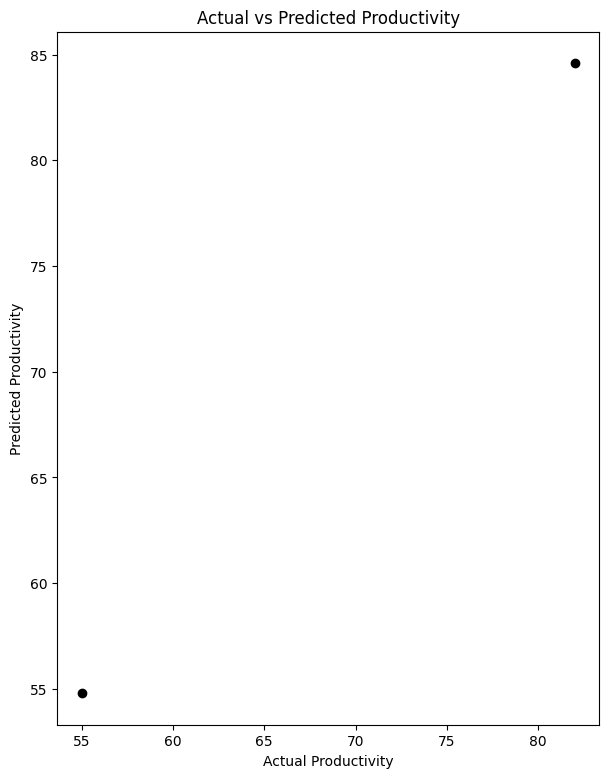

In [65]:
plt.figure(figsize=(7,9))

plt.scatter(y_test,y_pred,color="Black")

plt.xlabel("Actual Productivity")

plt.ylabel("Predicted Productivity")

plt.title("Actual vs Predicted Productivity")

plt.show()

# New Section